In [2]:
pip list

Package                 Version
----------------------- -----------
appnope                 0.1.4
asttokens               3.0.1
certifi                 2026.2.25
charset-normalizer      3.4.4
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.20
decorator               5.2.1
executing               2.2.1
fonttools               4.61.1
idna                    3.11
ipykernel               7.2.0
ipython                 9.10.0
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
joblib                  1.5.3
jupyter_client          8.8.0
jupyter_core            5.9.1
kiwisolver              1.4.9
matplotlib              3.10.8
matplotlib-inline       0.2.1
nest-asyncio            1.6.0
numpy                   2.4.2
packaging               26.0
pandas                  3.0.1
parso                   0.8.6
pexpect                 4.9.0
pillow                  12.1.1
pip                     26.0
platformdirs            

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
df = pd.read_csv('top2018.csv')

In [4]:
df = df.drop(columns=['id','name','artists','duration_ms','time_signature','mode','key'])

In [5]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)

In [6]:
scaled_features.shape

(100, 9)

In [7]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

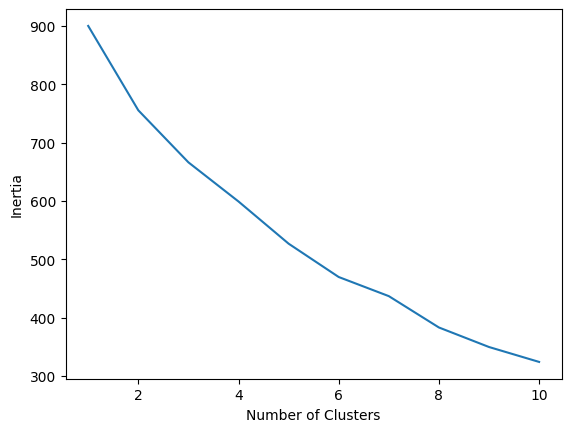

In [8]:
plt.plot(range(1, 11), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [9]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(scaled_features)
labels = kmeans.labels_
df['cluster'] = labels
print(df.head())

   danceability  energy  loudness  speechiness  acousticness  \
0         0.754   0.449    -9.211       0.1090        0.0332   
1         0.740   0.613    -4.880       0.1450        0.2580   
2         0.587   0.535    -6.090       0.0898        0.1170   
3         0.739   0.559    -8.011       0.1170        0.5800   
4         0.835   0.626    -5.833       0.1250        0.0589   

   instrumentalness  liveness  valence    tempo  cluster  
0          0.000083     0.552    0.357   77.169        1  
1          0.003720     0.123    0.473   75.023        3  
2          0.000066     0.131    0.140  159.847        1  
3          0.000000     0.112    0.439  140.124        2  
4          0.000060     0.396    0.350   91.030        1  


In [10]:
print(df['cluster'].value_counts())

cluster
1    33
3    32
2    19
0    16
Name: count, dtype: int64


In [11]:
centers = kmeans.cluster_centers_
print(centers)

[[ 0.29983557  0.07319523 -0.29891019  1.55385817 -0.56336959 -0.11687219
  -0.46366774  0.06548622  0.96950622]
 [-0.42619333 -0.02686838 -0.00757085 -0.37585637 -0.34813967 -0.1134253
   0.7616068  -0.63074515  0.09178073]
 [ 0.03804105 -1.07353979 -1.05782447 -0.03472115  1.36678651  0.4766389
  -0.32262286 -0.36627436  0.05165053]
 [ 0.26700721  0.62852465  0.78534581 -0.36871152 -0.17082567 -0.10759841
  -0.36201582  0.83518822 -0.61006949]]


In [12]:
centers_df = pd.DataFrame(centers, columns=df.drop("cluster", axis=1).columns)
print(centers_df)

   danceability    energy  loudness  speechiness  acousticness  \
0      0.299836  0.073195 -0.298910     1.553858     -0.563370   
1     -0.426193 -0.026868 -0.007571    -0.375856     -0.348140   
2      0.038041 -1.073540 -1.057824    -0.034721      1.366787   
3      0.267007  0.628525  0.785346    -0.368712     -0.170826   

   instrumentalness  liveness   valence     tempo  
0         -0.116872 -0.463668  0.065486  0.969506  
1         -0.113425  0.761607 -0.630745  0.091781  
2          0.476639 -0.322623 -0.366274  0.051651  
3         -0.107598 -0.362016  0.835188 -0.610069  


In [13]:
cluster_analysis = df.groupby("cluster").mean()
print(cluster_analysis)

         danceability    energy  loudness  speechiness  acousticness  \
cluster                                                                
0            0.755563  0.669625 -6.206313     0.277175      0.071851   
1            0.660879  0.655182 -5.691030     0.076479      0.119167   
2            0.721421  0.504105 -7.548579     0.111958      0.496174   
3            0.751281  0.749781 -4.288625     0.077222      0.158147   

         instrumentalness  liveness   valence       tempo  
cluster                                                    
0                0.000020  0.106788  0.497875  147.682125  
1                0.000066  0.242918  0.355070  122.533848  
2                0.007962  0.122458  0.409316  121.384053  
3                0.000144  0.118081  0.655750  102.424688  


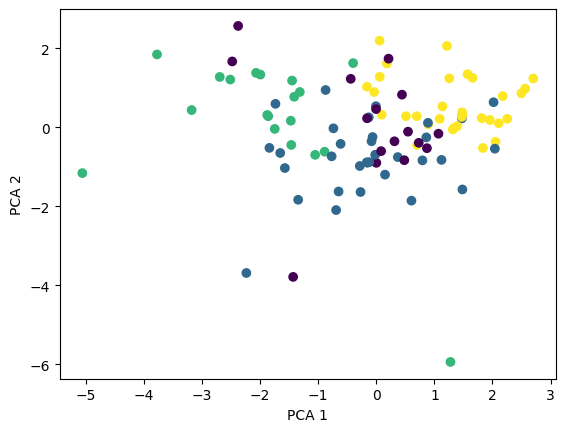

In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_features)

plt.scatter(X_pca[:,0], X_pca[:,1], c = labels)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [15]:
df['cluster'] = labels
cluster_0 = df[df['cluster'] == 0]
print(cluster_0[['name','artists']])
cluster_1 = df[df['cluster'] == 1]
print(cluster_1[['name','artists']])
cluster_2 = df[df['cluster'] == 2]
print(cluster_2[['name','artists']])
cluster_3 = df[df['cluster'] == 3]
print(cluster_3[['name','artists']])

KeyError: "None of [Index(['name', 'artists'], dtype='str')] are in the [columns]"

In [ ]:
cluster_labels = {
    0: "energetic / workout",
    1: "dance / club",
    2: "acoustic / calm",
    3: "fast / eDM"
}

for cluster_num, label in cluster_labels.items():
    print("\n", label)
    print("-" * 30)
    
    songs = df[df["cluster"] == cluster_num]
    
    for _, row in songs.iterrows():
        print(row["name"], "-", row["artists"])


 energetic / workout
------------------------------
Girls Like You (feat. Cardi B) - Maroon 5
Moonlight - XXXTENTACION
Te Bot? - Remix - Nio Garcia
Shape of You - Ed Sheeran
Sin Pijama - Becky G
Everybody Dies In Their Nightmares - XXXTENTACION

 dance / club
------------------------------
God's Plan - Drake
SAD! - XXXTENTACION
Psycho (feat. Ty Dolla $ign) - Post Malone
In My Feelings - Drake
IDGAF - Dua Lipa
Look Alive (feat. Drake) - BlocBoy JB
Jocelyn Flores - XXXTENTACION
Taste (feat. Offset) - Tyga
Eastside (with Halsey & Khalid) - benny blanco
changes - XXXTENTACION
River (feat. Ed Sheeran) - Eminem
Ric Flair Drip (& Metro Boomin) - Offset
Too Good At Goodbyes - Sam Smith
FEFE (feat. Nicki Minaj & Murda Beatz) - 6ix9ine
Nonstop - Drake
Fuck Love (feat. Trippie Redd) - XXXTENTACION
Walk It Talk It - Migos
Plug Walk - Rich The Kid
HUMBLE. - Kendrick Lamar
Perfect Duet (Ed Sheeran & Beyonc?) - Ed Sheeran
Young Dumb & Broke - Khalid
S?guelo Bailando - Ozuna
Bella - Wolfine
Yes Indee

In [ ]:
import pickle

with open('model.pkl','wb') as f:
    pickle.dump(kmeans, f)

NameError: name 'kmeans' is not defined